# Predicciones temporales de Carlos con modelos globales

Este notebook carga los modelos globales ya entrenados desde `new/models/tempvar_opt_allw`, aplica sus predicciones a los datos preprocesados de Carlos (`PC` y `EXERCISE`) y representa la clase de fatiga de cada ventana de 1 minuto a lo largo del tiempo.

Las predicciones se codifican como `Low = 0`, `Medium = 1` y `High = 2` solamente para el eje Y. Los resultados se guardan fuera de la carpeta de modelos.

In [12]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=UserWarning)

WORKSPACE_ROOT = Path(r'C:/Users/Carlo/Desktop/owncloud 2025-08-11 ECG')
MODELS_ROOT = WORKSPACE_ROOT / 'new' / 'models' / 'tempvar_opt_allw'
WCARLOS_ROOT = WORKSPACE_ROOT / 'new' / 'Wcarlos'
OUTPUT_ROOT = WORKSPACE_ROOT / 'new' / 'analysis_outputs' / 'wcarlos_model_predictions'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'PC': WCARLOS_ROOT / 'PC' / 'PROCESSED' / 'combined_features_1min.csv',
    'EXERCISE': WCARLOS_ROOT / 'EXERCISE' / 'PROCESSED' / 'combined_features_1min.csv',
}
MODEL_FILES = {
    'Logistic Regression': MODELS_ROOT / 'LOGISTIC_REGRESSION' / 'final_logistic_regression.joblib',
    'Random Forest': MODELS_ROOT / 'RANDOM_FOREST' / 'final_random_forest.joblib',
    'SVM': MODELS_ROOT / 'SVM' / 'final_svm.joblib',
    'XGBoost': MODELS_ROOT / 'XGBOOST' / 'final_xgboost.joblib',
}
METADATA_FILES = {
    name: path.with_name(path.stem + '_metadata.json')
    for name, path in MODEL_FILES.items()
}

for path in list(DATASETS.values()) + list(MODEL_FILES.values()) + list(METADATA_FILES.values()):
    if not path.exists():
        raise FileNotFoundError(f'No se encontro: {path}')

print(f'Salida: {OUTPUT_ROOT}')
print('Datasets:', ', '.join(DATASETS))
print('Modelos:', ', '.join(MODEL_FILES))

Salida: C:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs\wcarlos_model_predictions
Datasets: PC, EXERCISE
Modelos: Logistic Regression, Random Forest, SVM, XGBoost


In [13]:
models = {}
metadata = {}

for model_name, model_path in MODEL_FILES.items():
    models[model_name] = joblib.load(model_path)
    with METADATA_FILES[model_name].open(encoding='utf-8') as file:
        metadata[model_name] = json.load(file)

feature_columns = metadata['Logistic Regression']['feature_columns']
expected_labels = metadata['Logistic Regression'].get('labels', ['Low', 'Medium', 'High'])
if len(feature_columns) != 16:
    raise ValueError(f'Se esperaban 16 features y se encontraron {len(feature_columns)}')

for model_name, model_metadata in metadata.items():
    if model_metadata['feature_columns'] != feature_columns:
        raise ValueError(f'Las features de {model_name} no coinciden con las demas')

print('Features usadas:')
print(feature_columns)
print('Clases esperadas:', expected_labels)

Features usadas:
['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z', 'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
Clases esperadas: ['Low', 'Medium', 'High']


In [14]:
def unix_to_datetime(unix_values):
    values = pd.to_numeric(unix_values, errors='coerce')
    if values.isna().all():
        raise ValueError('La columna UNIX Timestamp no contiene valores numericos')
    magnitude = values.dropna().abs().median()
    if magnitude >= 1e18:
        unit = 'ns'
    elif magnitude >= 1e15:
        unit = 'us'
    elif magnitude >= 1e12:
        unit = 'ms'
    else:
        unit = 's'
    datetime_values = pd.to_datetime(values, unit=unit, errors='coerce', utc=True)
    return datetime_values + pd.Timedelta(hours=1), unit

def normalize_predictions(predictions, labels):
    labels = list(labels)
    label_by_text = {str(label).strip().lower(): label for label in labels}
    normalized = []
    for prediction in predictions:
        if pd.isna(prediction):
            normalized.append(np.nan)
            continue
        text = str(prediction).strip().lower()
        if text in label_by_text:
            normalized.append(label_by_text[text])
        elif isinstance(prediction, (int, float, np.integer, np.floating)) and int(prediction) in range(len(labels)):
            normalized.append(labels[int(prediction)])
        else:
            raise ValueError(f'Prediccion no reconocida: {prediction!r}')
    return np.asarray(normalized, dtype=object)

def load_dataset(dataset_name, csv_path):
    data = pd.read_csv(csv_path)
    if 'UNIX Timestamp' not in data.columns:
        raise KeyError(f'{csv_path.name} no contiene UNIX Timestamp')
    missing = [column for column in feature_columns if column not in data.columns]
    if missing:
        raise KeyError(f'{dataset_name} no contiene features: {missing}')
    data = data.copy()
    data['datetime_utc'], time_unit = unix_to_datetime(data['UNIX Timestamp'])
    data = data.sort_values('UNIX Timestamp', kind='stable').reset_index(drop=True)
    data.attrs['time_unit'] = time_unit
    return data

def predict_dataset(data, dataset_name):
    predictions = data[['UNIX Timestamp', 'datetime_utc']].copy()
    for model_name, model in models.items():
        raw_predictions = model.predict(data[feature_columns])
        predictions[model_name] = normalize_predictions(raw_predictions, expected_labels)
        invalid = ~predictions[model_name].isin(expected_labels)
        if invalid.any():
            raise ValueError(f'{model_name} produjo clases no validas en {dataset_name}')
    predictions['dataset'] = dataset_name
    return predictions

all_data = {}
all_predictions = {}
for dataset_name, csv_path in DATASETS.items():
    all_data[dataset_name] = load_dataset(dataset_name, csv_path)
    all_predictions[dataset_name] = predict_dataset(all_data[dataset_name], dataset_name)
    output_csv = OUTPUT_ROOT / f'{dataset_name.lower()}_predictions.csv'
    all_predictions[dataset_name].to_csv(output_csv, index=False)
    print(f'{dataset_name}: {len(all_predictions[dataset_name])} ventanas, tiempo en {all_data[dataset_name].attrs["time_unit"]}')
    display(all_predictions[dataset_name].head())

PC: 153 ventanas, tiempo en ns


,UNIX Timestamp,datetime_utc,Logistic Regression,Random Forest,SVM,XGBoost,dataset
0,1787922065267126924,2026-08-28 14:01:05.267126924+00:00,Low,Low,Low,Low,PC
1,1787922125274596503,2026-08-28 14:02:05.274596503+00:00,Medium,High,Medium,Low,PC
2,1787922185280112962,2026-08-28 14:03:05.280112962+00:00,Medium,Medium,High,Medium,PC
3,1787922245286697555,2026-08-28 14:04:05.286697555+00:00,High,High,High,High,PC
4,1787922305292122464,2026-08-28 14:05:05.292122464+00:00,High,High,High,High,PC


EXERCISE: 119 ventanas, tiempo en ns


,UNIX Timestamp,datetime_utc,Logistic Regression,Random Forest,SVM,XGBoost,dataset
0,1787942422556783706,2026-08-28 19:40:22.556783706+00:00,Low,Low,Low,Low,EXERCISE
1,1787942482559680664,2026-08-28 19:41:22.559680664+00:00,Medium,Medium,Medium,Medium,EXERCISE
2,1787942542561143320,2026-08-28 19:42:22.561143320+00:00,Medium,High,Medium,Medium,EXERCISE
3,1787942602561804262,2026-08-28 19:43:22.561804262+00:00,Low,Low,Low,Low,EXERCISE
4,1787942662561871336,2026-08-28 19:44:22.561871336+00:00,Low,Low,Low,Low,EXERCISE


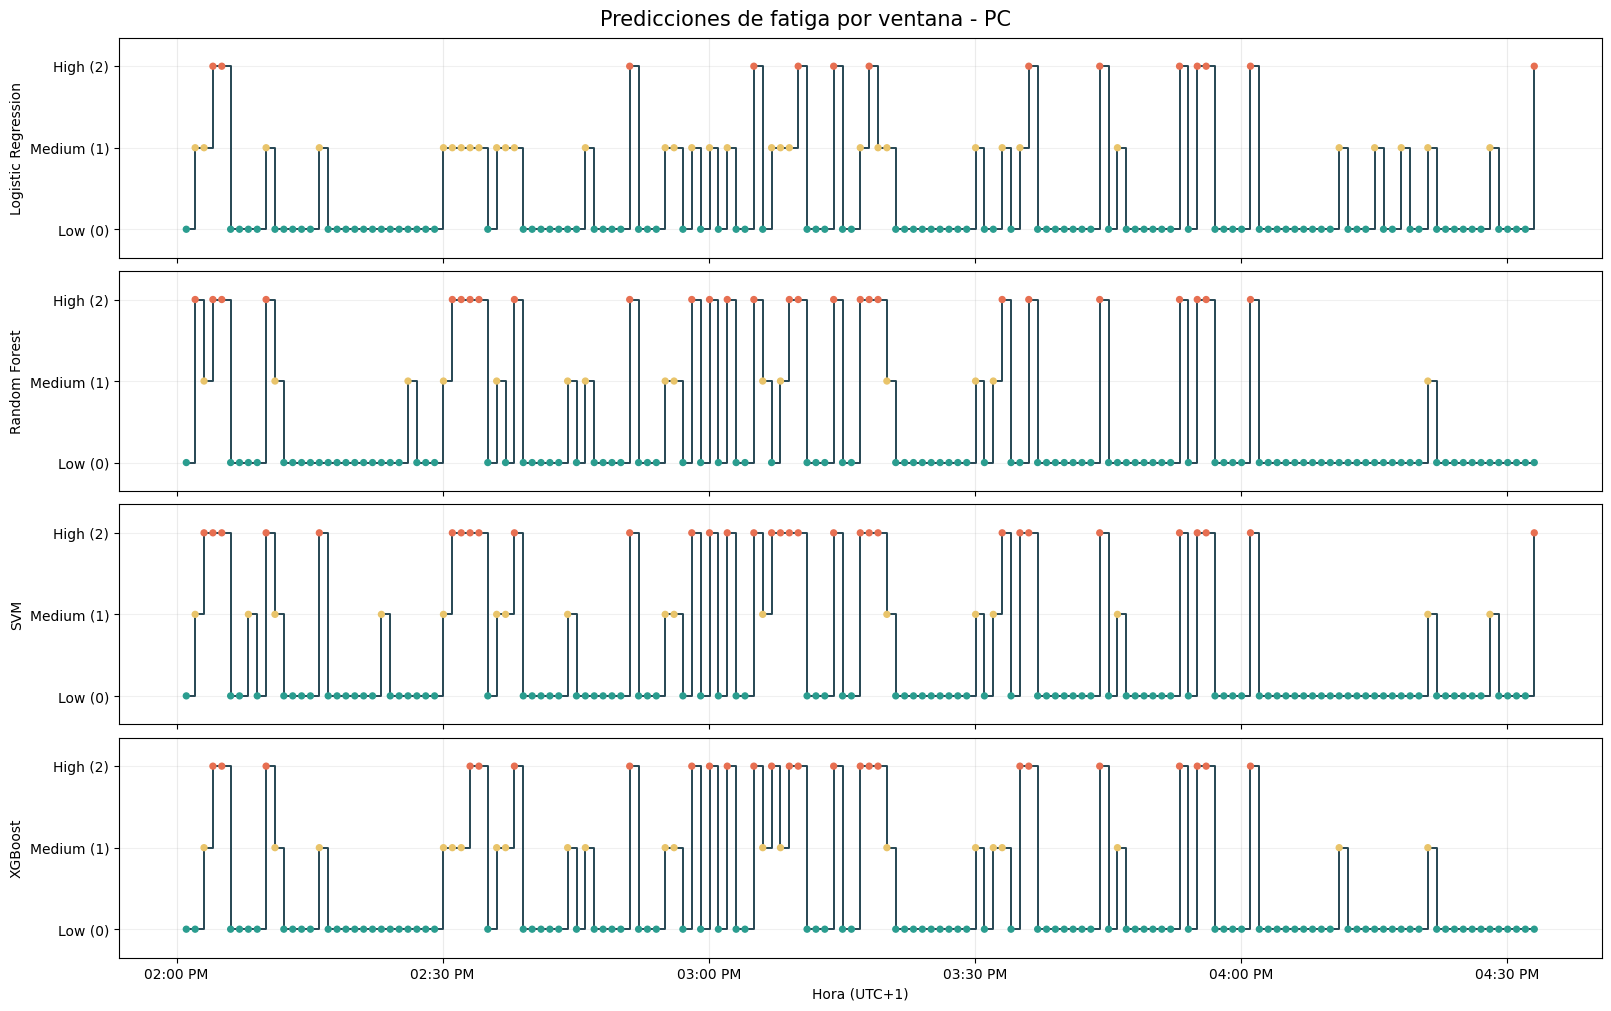

Grafica guardada en: C:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs\wcarlos_model_predictions\pc_predictions_temporal.png


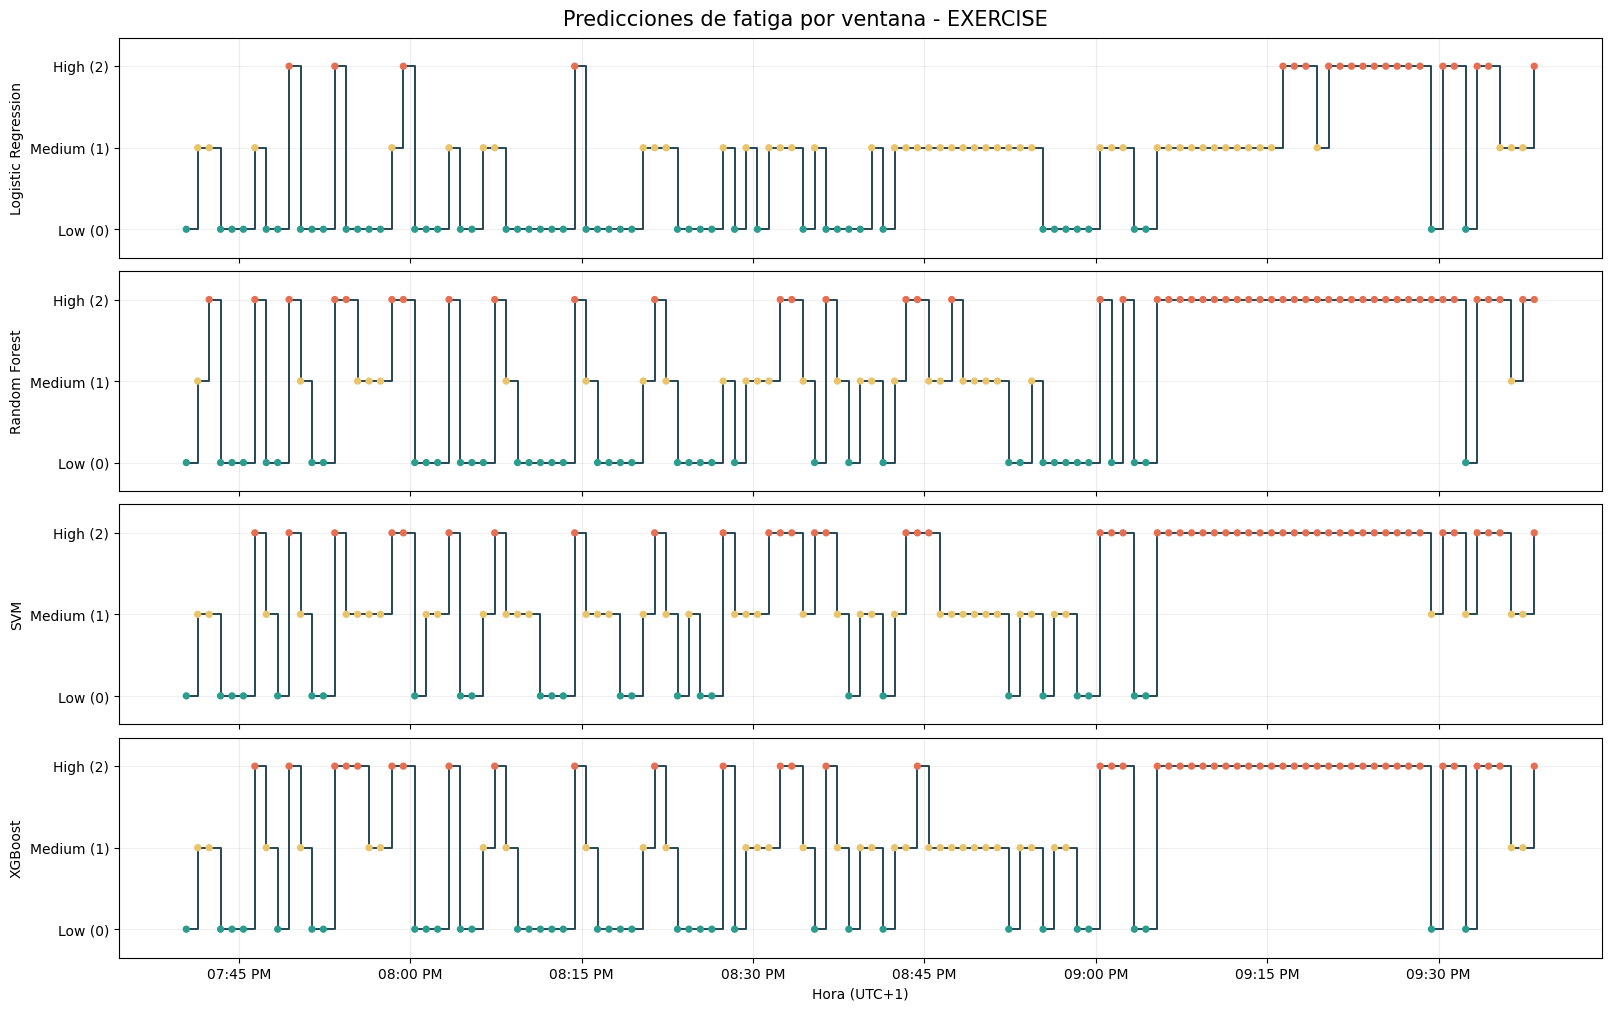

Grafica guardada en: C:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs\wcarlos_model_predictions\exercise_predictions_temporal.png


In [15]:
from matplotlib.dates import DateFormatter

class_to_number = {label: number for number, label in enumerate(expected_labels)}
colors = {'Low': '#2a9d8f', 'Medium': '#e9c46a', 'High': '#e76f51'}

for dataset_name, predictions in all_predictions.items():
    figure, axes = plt.subplots(len(models), 1, figsize=(16, 10), sharex=True, constrained_layout=True)
    axes = np.atleast_1d(axes)
    for axis, model_name in zip(axes, models):
        values = predictions[model_name].map(class_to_number)
        axis.step(predictions['datetime_utc'], values, where='post', color='#264653', linewidth=1.4)
        axis.scatter(predictions['datetime_utc'], values, c=predictions[model_name].map(colors), s=18, zorder=3)
        axis.set_yticks(range(len(expected_labels)))
        axis.set_yticklabels([f'{label} ({number})' for number, label in enumerate(expected_labels)])
        axis.set_ylim(-0.35, len(expected_labels) - 0.65)
        axis.set_ylabel(model_name)
        axis.grid(axis='x', alpha=0.25)
        axis.grid(axis='y', alpha=0.18)
    axes[-1].xaxis.set_major_formatter(DateFormatter('%I:%M %p'))
    axes[-1].set_xlabel('Hora (UTC+1)')
    figure.suptitle(f'Predicciones de fatiga por ventana - {dataset_name}', fontsize=15)
    figure_path = OUTPUT_ROOT / f'{dataset_name.lower()}_predictions_temporal.png'
    figure.savefig(figure_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Grafica guardada en: {figure_path}')

In [16]:
summary_rows = []
for dataset_name, predictions in all_predictions.items():
    for model_name in models:
        counts = predictions[model_name].value_counts().reindex(expected_labels, fill_value=0)
        summary_rows.append({
            'dataset': dataset_name,
            'model': model_name,
            **{f'{label}_windows': int(counts[label]) for label in expected_labels},
        })
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTPUT_ROOT / 'prediction_summary.csv', index=False)
display(summary)
print(f'Resultados escritos en: {OUTPUT_ROOT}')

,dataset,model,Low_windows,Medium_windows,High_windows
0,PC,Logistic Regression,106,33,14
1,PC,Random Forest,111,15,27
2,PC,SVM,104,17,32
3,PC,XGBoost,107,21,25
4,EXERCISE,Logistic Regression,50,48,21
5,EXERCISE,Random Forest,42,26,51
6,EXERCISE,SVM,26,42,51
7,EXERCISE,XGBoost,37,33,49


Resultados escritos en: C:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs\wcarlos_model_predictions


## Estadistica de aciertos y errores

Para `PC`, una prediccion `High` se considera error; `Low` y `Medium` son correctas.
Para `EXERCISE`, `Low` es error; `Medium` y `High` son correctas.
Ademas, el ejercicio se divide en caminadora (09:05-09:25 PM) y trote (09:25-09:35 PM).

In [17]:
def calculate_accuracy_table(prediction_data, dataset_name, correct_labels, activity='Todo el registro'):
    rows = []
    for model_name in models:
        valid_predictions = prediction_data[model_name].dropna()
        total_windows = len(valid_predictions)
        correct_windows = int(valid_predictions.isin(correct_labels).sum())
        error_windows = total_windows - correct_windows
        rows.append({
            'dataset': dataset_name,
            'activity': activity,
            'model': model_name,
            'total_windows': total_windows,
            'correct_windows': correct_windows,
            'error_windows': error_windows,
            'correct_percent': round(100 * correct_windows / total_windows, 2) if total_windows else np.nan,
            'error_percent': round(100 * error_windows / total_windows, 2) if total_windows else np.nan,
        })
    return pd.DataFrame(rows)

pc_statistics = calculate_accuracy_table(all_predictions['PC'], 'PC', {'Low', 'Medium'})
exercise_statistics = calculate_accuracy_table(all_predictions['EXERCISE'], 'EXERCISE', {'Medium', 'High'})
overall_statistics = pd.concat([pc_statistics, exercise_statistics], ignore_index=True)
overall_statistics.to_csv(OUTPUT_ROOT / 'accuracy_error_statistics_overall.csv', index=False)
display(overall_statistics)

exercise_predictions = all_predictions['EXERCISE'].copy()
exercise_time = pd.to_datetime(exercise_predictions['datetime_utc'], utc=True)
exercise_date = exercise_time.dt.normalize().iloc[0]
treadmill_start = exercise_date + pd.Timedelta(hours=21, minutes=5)
treadmill_end = exercise_date + pd.Timedelta(hours=21, minutes=25)
jogging_start = treadmill_end
jogging_end = exercise_date + pd.Timedelta(hours=21, minutes=35)

treadmill_mask = (exercise_time >= treadmill_start) & (exercise_time < treadmill_end)
jogging_mask = (exercise_time >= jogging_start) & (exercise_time < jogging_end)
treadmill_predictions = exercise_predictions.loc[treadmill_mask].copy()
jogging_predictions = exercise_predictions.loc[jogging_mask].copy()

treadmill_statistics = calculate_accuracy_table(treadmill_predictions, 'EXERCISE', {'Medium', 'High'}, 'Caminadora 09:05-09:25 PM')
jogging_statistics = calculate_accuracy_table(jogging_predictions, 'EXERCISE', {'High'}, 'Trote 09:25-09:35 PM')
exercise_activity_statistics = pd.concat([treadmill_statistics, jogging_statistics], ignore_index=True)
exercise_activity_statistics.to_csv(OUTPUT_ROOT / 'accuracy_error_statistics_exercise_activities.csv', index=False)
display(exercise_activity_statistics)
print(f'Ventanas caminadora: {len(treadmill_predictions)}')
print(f'Ventanas trote: {len(jogging_predictions)}')
print(f'Estadisticas guardadas en: {OUTPUT_ROOT}')

,dataset,activity,model,total_windows,correct_windows,error_windows,correct_percent,error_percent
0,PC,Todo el registro,Logistic Regression,153,139,14,90.85,9.15
1,PC,Todo el registro,Random Forest,153,126,27,82.35,17.65
2,PC,Todo el registro,SVM,153,121,32,79.08,20.92
3,PC,Todo el registro,XGBoost,153,128,25,83.66,16.34
4,EXERCISE,Todo el registro,Logistic Regression,119,69,50,57.98,42.02
5,EXERCISE,Todo el registro,Random Forest,119,77,42,64.71,35.29
6,EXERCISE,Todo el registro,SVM,119,93,26,78.15,21.85
7,EXERCISE,Todo el registro,XGBoost,119,82,37,68.91,31.09


,dataset,activity,model,total_windows,correct_windows,error_windows,correct_percent,error_percent
0,EXERCISE,Caminadora 09:05-09:25 PM,Logistic Regression,20,20,0,100.0,0.0
1,EXERCISE,Caminadora 09:05-09:25 PM,Random Forest,20,20,0,100.0,0.0
2,EXERCISE,Caminadora 09:05-09:25 PM,SVM,20,20,0,100.0,0.0
3,EXERCISE,Caminadora 09:05-09:25 PM,XGBoost,20,20,0,100.0,0.0
4,EXERCISE,Trote 09:25-09:35 PM,Logistic Regression,10,8,2,80.0,20.0
5,EXERCISE,Trote 09:25-09:35 PM,Random Forest,10,9,1,90.0,10.0
6,EXERCISE,Trote 09:25-09:35 PM,SVM,10,8,2,80.0,20.0
7,EXERCISE,Trote 09:25-09:35 PM,XGBoost,10,8,2,80.0,20.0


Ventanas caminadora: 20
Ventanas trote: 10
Estadisticas guardadas en: C:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs\wcarlos_model_predictions
